# Tutorial FigureCollection

In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import pandas as pd
import src.fluorophore_systems as fs
import src.miscellaneous as mi

%load_ext autoreload
%autoreload 2

In [2]:
rates = [['k_tS0_tS1', 7e6, "excitation", "EXC", False],  
         ['k_tS1_tS0', 1e9, "fluorescent emission", "FLU", True], 
         ['k_tS1_tT1', 1e6, "intersystem crossing ST", "ISCST", False],   
         ['k_tT1_tS0', 5e5, "intersystem crossing TS", "ISCTS", False],
         ['k_tS1_tS0', 1e9, "internal conversion S", "ICS", False],
         ['k_tS1_Cis', 2e7, "isomerization", "ISO", False],
         ['k_Cis_tS0', 1e5, "backisomerization", "BISO", False],
         ['k_tT1_OFF', 1.4e6, "reduction", "RED", False],
         ['k_OFF_tS0', 1e1, "oxidation", "OX", False]]

In [3]:
system = fs.Cy5dSTORMModel(number_fluorophores=2, distances=1, rates=rates)
system.simulate(n_steps=int(1e7), seed=100)
system.process()
system.emitters(photon_collection_rate=0.5, resample="5ms", emccd_gain=10)
system.fcs(normalize=True, log=True, m=2, deltat="10us")

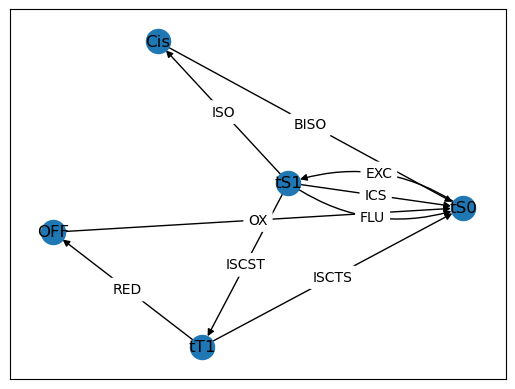

In [4]:
fig, ax = system.plot.network(10)

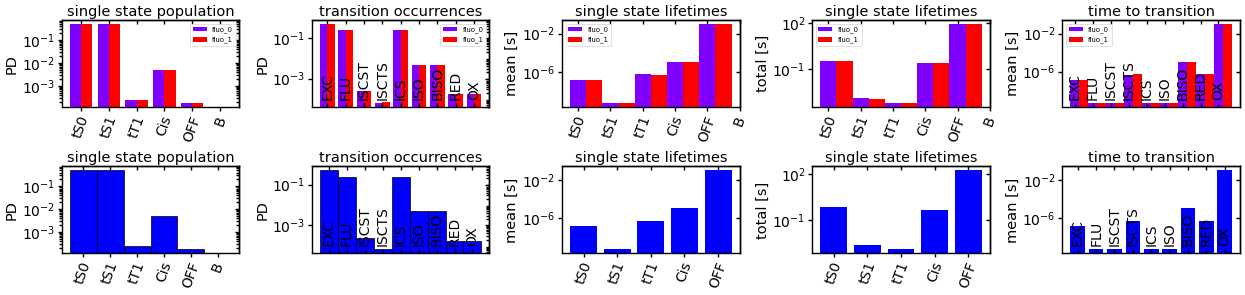

In [5]:
fig, ax = system.plot.populations(mode="single_states", single_fluorophores=True, scale=0.5, ncols=5, nrows=2, fig_width=25, fig_height=6)
_, _ = system.plot.populations(mode="single_states", single_fluorophores=False, scale=1, fig=fig, axes=ax[1, 0])
_, _ = system.plot.populations(mode='transitions', single_fluorophores=True, scale=1, fig=fig, axes=ax[0, 1])
_, _ = system.plot.populations(mode='transitions', single_fluorophores=False, scale=1, fig=fig, axes=ax[1, 1])
_, _ = system.plot.lifetimes(mode='single_states', statistic='mean', single_fluorophores=True, scale=1, fig=fig, axes=ax[0, 2])
_, _ = system.plot.lifetimes(mode='single_states', statistic='mean', single_fluorophores=False, scale=1, fig=fig, axes=ax[1, 2])
_, _ = system.plot.lifetimes(mode='single_states', statistic='total', single_fluorophores=True, scale=1, fig=fig, axes=ax[0, 3])
_, _ = system.plot.lifetimes(mode='single_states', statistic='total', single_fluorophores=False, scale=1, fig=fig, axes=ax[1, 3])
_, _ = system.plot.lifetimes(mode='transitions', single_fluorophores=True, scale=1, fig=fig, axes=ax[0, 4])
_, _ = system.plot.lifetimes(mode='transitions', single_fluorophores=False, scale=1, fig=fig, axes=ax[1, 4])
fig.tight_layout()

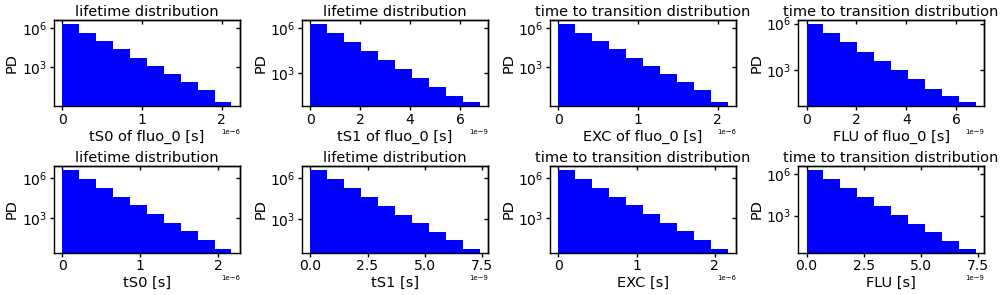

In [6]:
fig, ax = system.plot.individual_lifetimes(fluorophore_id=0, single_state_id=0, transition_id=None, scale=0.5, ncols=4, nrows=2, fig_width=20, fig_height=6)
_, _ = system.plot.individual_lifetimes(fluorophore_id=None, single_state_id=0, transition_id=None, scale=1, fig=fig, axes=ax[1, 0])
_, _ = system.plot.individual_lifetimes(fluorophore_id=0, single_state_id=1, transition_id=None, scale=1, fig=fig, axes=ax[0, 1])
_, _ = system.plot.individual_lifetimes(fluorophore_id=None, single_state_id=1, transition_id=None, scale=1, fig=fig, axes=ax[1, 1])
_, _ = system.plot.individual_lifetimes(fluorophore_id=0, single_state_id=None, transition_id=0, scale=1, fig=fig, axes=ax[0, 2])
_, _ = system.plot.individual_lifetimes(fluorophore_id=None, single_state_id=None, transition_id=0, scale=1, fig=fig, axes=ax[1, 2])
_, _ = system.plot.individual_lifetimes(fluorophore_id=0, single_state_id=None, transition_id=1, scale=1, fig=fig, axes=ax[0, 3])
_, _ = system.plot.individual_lifetimes(fluorophore_id=None, single_state_id=None, transition_id=1, scale=1, fig=fig, axes=ax[1, 3])
fig.tight_layout()

## Emission analysis

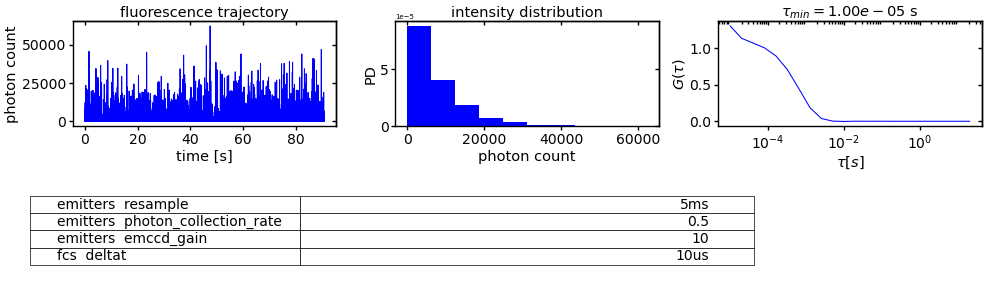

In [81]:
fig, ax = system.plot.emission_events(time_series=True, scale=0.5, ncols=3, nrows=3, fig_width=20, fig_height=9)
_, _ = system.plot.emission_events(time_series=False, scale=1, fig=fig, axes=ax[0, 1])
_, _ = system.plot.fcs(normalize_to=4, fig=fig, axes=ax[0, 2])
fig = mi.delete_subplots(fig, ax, 3)
fig = system.plot.add_table(fig, grid=312, level_0=['emitters', 'fcs'], level_1=[['resample', 'photon_collection_rate', 'emccd_gain'], ['deltat']],
                            scale=(0.5, 2), fontsize=20)
#fig = system.plot.add_table(fig, grid=313, level_0='fcs', scale=(0.5, 2), fontsize=20)
fig.tight_layout()

## ON OFF periods
#### ON periods and OFF periods
An ON period is a number of consecutive frames where each frame contains a minimum amount of emissions ($>$ threshold). 
An OFF period is a number of consecutive frames where each frame contains a maximum amount of emissions ($\le$ threshold).

#### Time series of ON and OFF periods
Displays all ON (or OFF) periods consecutively with their number of frames. Note that each ON period is followed by an OFF period and vice versa.


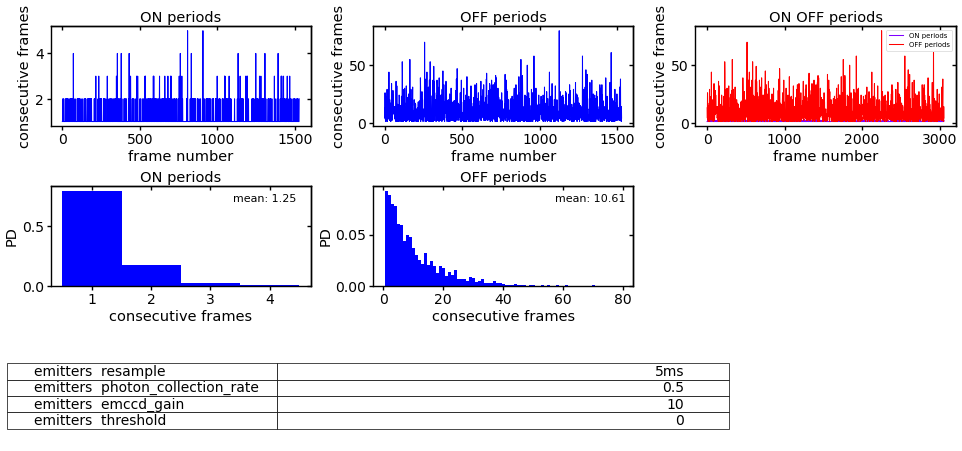

In [104]:
fig, ax = system.plot.on_off(mode='on', time_series=True, scale=0.5, ncols=3, nrows=3, fig_width=20, fig_height=9)
_, _ = system.plot.on_off(mode='off', time_series=True, scale=1, fig=fig, axes=ax[0, 1])
_, _ = system.plot.on_off(mode='mesh', time_series=True, scale=1, fig=fig, axes=ax[0, 2])
_, _ = system.plot.on_off(mode='on', time_series=False, scale=1, fig=fig, axes=ax[1, 0])
_, _ = system.plot.on_off(mode='off', time_series=False, scale=1, fig=fig, axes=ax[1, 1])
fig = mi.delete_subplots(fig, ax, 5)
fig = system.plot.add_table(fig, grid=313, level_0=['emitters'], level_1=[['resample', 'photon_collection_rate', 'emccd_gain', 'threshold']],
                            scale=(0.5, 2), fontsize=20)
fig.tight_layout()